# Credit card fraud detection

## Introduction

The machine learning project aims to detect fraudulent credit card transaction, which is a growing problem for the banking industry and also for consumers. Due to growing scam and social engineering activities more people are victims. Therefore there are multiple stakeholders (regulatory authorities (in europe: EBA & ECB), banks, consumers) interested in a sufficient fraud prevention and detection. 



The project is a classification problem, with highly unbalanced proportions of our to explainable variable y (is_fraud). Classifing the transaction into fraudulent transaction, while actually being fraudulent transaction is crucial for the credit card originating bank. Not detecting fraudulent transaction leads to financial liability damages, binding workers recourses and also damaging the reputation of the bank as safe financial service provider. Marked false positive transactions are also a problem for the bank business. Getting warning messages to the client or even blocking the credit card results into less card activity and therefore less revenue and profit for the bank. In the worst case clients will even terminate their credit card contract, because the credit card is not reliable when it should be. The declined using of a (business) credit card, for a late hotel check in, is horrible and for sure not a nice experience in a tight working schedule.    


The credit card data (most likely synthetic data) is downloaded from Hugging face (https://huggingface.co/datasets/pointe77/credit-card-transaction), without providing any descriptions.Nevertheless the used variables are quit obvious, by their structure and their content. So the qualitative data description will be conducted on industrial experience and best guesses.


The Script CC_Fraud_DATA_Prep.ipynb already creates via feature engineering variables from the initial dataset which is based on the initial Hugging Face dataset and the FBI Crime Data. To make this script cleaner this script starts, with the used dataset description and then provides the model usage.  

## General steps in this Project
As first step the dataset is changed and enriched with constructed variables (feature engineering) to get a better explanibility for classification fraud, whereas is_fraud=1 is a fraudulent transaction. The steps of constructing variables are seperated in the script (CC_Fraud_Data_Prep.ipynb). A descriptive analysis of the constructed and original dataset is conducted, by using basic descriptive statistics and some visualisations. Since the dataset is not just a simple cross sectional dataset, not considering any time dependet relations could be fatally missing any crucial trends. A short time series analysis of our dataset is therefore included.

The feature enigineering of variables leads in multiple variables which are highly correlated to each other (by being based on the same features), since it is a Tree based algorithm, this issue is not adressed as it would be if we also contained the lasso regression and linear support vector machine. Nevertheless the project contains LightGBM for the purpose of deciding and selecting variables, which variables more efficiently leads to a better explanibilty. 

Both procedures are included, to get a more decisive analysis of the variable, whereas the lasso regression investigates linear relationship it provides negative or positive links to our fraud marker (y), which is a valuable information for the bank and future steps in avoiding fraud.  


In [1]:
# Importing standard packages
import polars as pl # Faster then pandas, 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # visualization
#import sklearn as 

from geopy.distance import distance #, geodesic, great_circle # Feature Engineering module for Geodata

In [2]:
# reading in the datasets

cc_train =  pl.read_parquet("credit_card_trans_train.parquet")
cc_test  = pl.read_parquet("credit_card_trans_test.parquet")
# cc_comb = pl.concat([cc_train, cc_test])
# del(cc_train, cc_test)
ID_cols = ['Owner_ID', 'cc_num', 'trans_num','trans_date_trans_time','merchant', 'dist_client_merchant']
cc_train_ID = cc_train.select(ID_cols)
cc_test_ID = cc_test.select(ID_cols)

cc_train = cc_train.drop(['Owner_ID', 'cc_num','trans_date_trans_time','merchant', 'dist_client_merchant'])
cc_test = cc_test.drop(['Owner_ID', 'cc_num','trans_date_trans_time','merchant', 'dist_client_merchant'])


In [3]:
cc = cc_train
# Trans_num as ID and seperate Information DataFrame 
# To make the Data_Frame nicer to handle all Identifier variables and some string variables are seperated from the dataset:
#  
"""
cc_ID = 
print(f"Columns: {cc.columns.drop('')}")
"""
cc.head(5)


trans_num,category,amt,gender,city_pop,job,is_fraud,State_Risk_Rating,trans_date,trans_time_diff,travel_time_km,daily_trans,daily_trans_lagged,net_binary,Population_Density,birth_year,generation,net_binary_comb_travel_time,net_binary_comb_trans_time
str,str,f64,str,i64,str,i64,i64,date,f64,f64,u32,u32,i32,str,i32,str,f64,f64
"""98e3dcf98101146a577f85a34e58fe…","""misc_net""",38.731176,"""F""",1645,"""Information systems manager""",0,2353556,2019-01-01,0.0,0.0,1,0,0,"""Village""",1986,"""Millennials""",0.0,0.0
"""498120fc45d277f7c88e3dba79c338…","""gas_transport""",205.568402,"""F""",1645,"""Information systems manager""",0,2353556,2019-01-02,71862.0,0.001806,4,0,1,"""Village""",1986,"""Millennials""",0.001806,71862.0
"""95f514bb993151347c7acdf8505c3d…","""gas_transport""",86.873989,"""F""",1645,"""Information systems manager""",0,2353556,2019-01-02,159.0,2.755731,4,4,1,"""Village""",1986,"""Millennials""",2.755731,159.0
"""4f0c1a14e0aa7eb56a490780ef9268…","""kids_pets""",78.630423,"""F""",1645,"""Information systems manager""",0,2353556,2019-01-02,13838.0,0.033509,4,4,1,"""Village""",1986,"""Millennials""",0.033509,13838.0
"""3b2ebd3af508afba959640893e1e82…","""home""",65.831735,"""F""",1645,"""Information systems manager""",0,2353556,2019-01-02,1952.0,0.305505,4,4,1,"""Village""",1986,"""Millennials""",0.305505,1952.0


### A Short general description of the dataset and the difference to the original dataset.

The first variables contain Keyident data on different levels. We originated an unique OwnerID instead of the name, a CC_num (Credit Card Number) and trans_num (Transaction number) already existed, to identify fraudulent transaction and the related owner and card. 
The original dataset contains location data which is partly written as string dtype and also in latitude and longitude of customer and also merchant data. Since we derived in the feature engineering script the following variables: #LIST# -> The Variables: street	city	state	zip	lat	long merch_lat	merch_long merch_zipcode are deleted. 
The transaction date information is used to derive daily and weekly timestamps and based on these timestamps and location data the following features are derived: #LIST#.



Threshold in noon (2020, 6, 21)

## First Overview of the Data

### Qualitative Description of the DATA, What the Variables mean.



In [4]:
# Since we got labeled data we can check the Time Series of fraud activity (at least for this data, the reality might be different with unlabeled data):
cc = cc_train
min_date = cc['trans_date'].min()

# weeks since start
cc = cc.with_columns(
    ((pl.col('trans_date') - min_date).dt.total_days() / 7).floor().cast(pl.Int32).alias('week_index')
)

# Aggregation weekly data
weekly_stats = cc.group_by(['week_index']).agg([
    pl.len().alias('total_transactions'),
    pl.col('is_fraud').sum().alias('fraud_count'),
    (pl.col('is_fraud').sum() / pl.len() * 100).alias('fraud_percentage')
]).sort(['week_index'])


trans_num,category,amt,gender,city_pop,job,is_fraud,State_Risk_Rating,trans_time_diff,travel_time_km,daily_trans,daily_trans_lagged,net_binary,Population_Density,birth_year,generation,net_binary_comb_travel_time,net_binary_comb_trans_time
str,str,f64,str,i64,str,i64,i64,f64,f64,u32,u32,i32,str,i32,str,f64,f64
"""98e3dcf98101146a577f85a34e58fe…","""misc_net""",38.731176,"""F""",1645,"""Information systems manager""",0,2353556,0.0,0.0,1,0,0,"""Village""",1986,"""Millennials""",0.0,0.0
"""498120fc45d277f7c88e3dba79c338…","""gas_transport""",205.568402,"""F""",1645,"""Information systems manager""",0,2353556,71862.0,0.001806,4,0,1,"""Village""",1986,"""Millennials""",0.001806,71862.0
"""95f514bb993151347c7acdf8505c3d…","""gas_transport""",86.873989,"""F""",1645,"""Information systems manager""",0,2353556,159.0,2.755731,4,4,1,"""Village""",1986,"""Millennials""",2.755731,159.0
"""4f0c1a14e0aa7eb56a490780ef9268…","""kids_pets""",78.630423,"""F""",1645,"""Information systems manager""",0,2353556,13838.0,0.033509,4,4,1,"""Village""",1986,"""Millennials""",0.033509,13838.0
"""3b2ebd3af508afba959640893e1e82…","""home""",65.831735,"""F""",1645,"""Information systems manager""",0,2353556,1952.0,0.305505,4,4,1,"""Village""",1986,"""Millennials""",0.305505,1952.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ad7dfdf0aaa36cd7985dd1f35ca0e2…","""personal_care""",391.859479,"""M""",532,"""Audiological scientist""",0,2675478,30740.0,0.014442,4,4,1,"""Village""",1956,"""Boomer""",0.014442,30740.0
"""6d427d735c9f9b2fd480f2c24b6525…","""gas_transport""",541.232555,"""M""",532,"""Audiological scientist""",0,2675478,12962.0,0.028775,4,0,1,"""Village""",1956,"""Boomer""",0.028775,12962.0
"""9814049bcc69fb31d81f4a907f2fe2…","""shopping_net""",1354.000769,"""M""",532,"""Audiological scientist""",0,2675478,7618.0,0.043586,4,4,0,"""Village""",1956,"""Boomer""",0.0,0.0


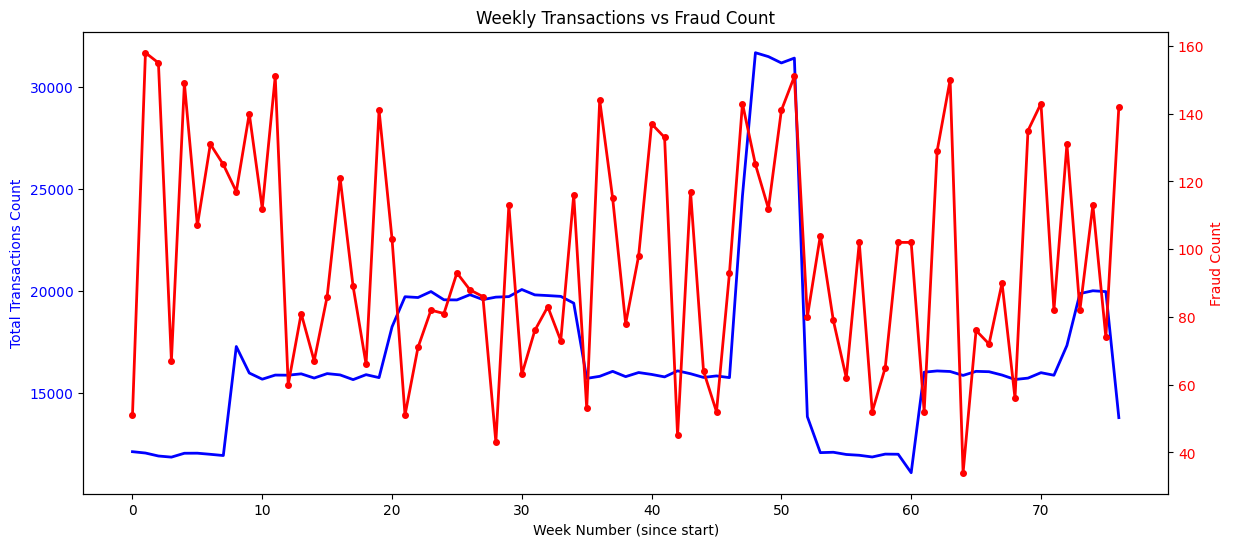

In [5]:
# Plot using week_index
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(weekly_stats['week_index'], weekly_stats['total_transactions'], 
         label='Total Transactions', color='blue', linewidth=2)
ax1.set_xlabel('Week Number (since start)')
ax1.set_ylabel('Total Transactions Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(weekly_stats['week_index'], weekly_stats['fraud_count'], 
         label='Fraud Count', color='red', linewidth=2, marker='o', markersize=4)
ax2.set_ylabel('Fraud Count', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Weekly Transactions vs Fraud Count')

cc.drop(['trans_date','week_index'])

Checking the Time Series visualy, the following seems to apply:
The fraud count seems to be stationary. Dickey Fuller Test can be conducted as addition.
The CC usage seems to get some seasonality, unfortunately the data does not cover multiple years (annualy seasonality seems to be dominating) and therefore it might be unsufficient to feature engineer. 
The rise of CC usage for christmas and then the low account balance afterwards is clearly visable. 

No strong trend (fraud isn't systematically increasing or decreasing)
No seasonality (no weekly, monthly, or quarterly patterns)
No memory effect (past fraud doesn't predict future fraud)

Variable description of included variables:
- [category]
- [amt]

Variable description of the constructed variables:
- [State_Risk_Rating] 
- Transaction time difference [trans_time_diff] 
- Travel Distance in km per second [travel_time_km] 
- [daily_trans_lagged] 
- [net_binary]
- [Population_Density]
- [birth_year]
- [net_binary_comb_travel_time]
- [net_binary_comb_trans_time]


## ENCODING

II.1) Feature Representation
TODO: Adapt text to newer version
By using a ordinal range/categories for the variables,  it results in some better model performances. 
(Linear SVM, Logistic Regression) -Linear SVM for this data not used.
Whereas we will use the scaled integer values, for our tree based models. (XGBoost, LightGBM)  

The following Variables are therefore transformed:

- City Population
- State Risk Rating

Ordinal text variables:
Following the Lab4 - OrdinalEncoder will be used from the preprocessing module in Scikit-learn. 

In comparison to the algorithm of the Machine Learning course provided by UWM, in this tree based pipeline a more simplified preprocessing is conducted. First of all, since there are no missings in the dataset (Which is not totally unrealistic for those personal data and transaction data, considering the high regulation of data lineage and data quality in banks, their credit card transaction data is originated in their banking systems. It is more likelly that the personal data is not actual, which happens often, but is not easy to measure or consider.) the imputation step is skipped.
The scaling of numeric variables is for tree based alorithms skipped as well, since the splits are based on value comparisons.


In [6]:
# cleaning up preprocessing and the pipeline:
"""
Dr. Example:

num_values_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),      # Imputing is not necessary in this dataset
    MinMaxScaler(),                      # Numeric variables does not need a scaling for TreeBased Algos
)
cat_values_pipeline = make_pipeline(
    OrdinalEncoder(handle_unknown='error'), # Encoding more to differiante
)

preprocessing_pipeline = ColumnTransformer([
    ('num_attributes_steps', num_values_pipeline, data.select_dtypes('number').columns),
    ('cat_attributes_steps', cat_values_pipeline, ('protocol_type', 'service', 'flag', 'labels')),
])

THEN AFTER preprocessing_pipeline:

data_preprocessed = pd.DataFrame(
    preprocessing_pipeline.fit_transform(data), 
    columns=preprocessing_pipeline.get_feature_names_out(),
    index=data.index,
)

"""


"\nDr. Example:\n\nnum_values_pipeline = make_pipeline(\n    SimpleImputer(strategy='mean'),      # Imputing is not necessary in this dataset\n    MinMaxScaler(),                      # Numeric variables does not need a scaling for TreeBased Algos\n)\ncat_values_pipeline = make_pipeline(\n    OrdinalEncoder(handle_unknown='error'), # Encoding more to differiante\n)\n\npreprocessing_pipeline = ColumnTransformer([\n    ('num_attributes_steps', num_values_pipeline, data.select_dtypes('number').columns),\n    ('cat_attributes_steps', cat_values_pipeline, ('protocol_type', 'service', 'flag', 'labels')),\n])\n\nTHEN AFTER preprocessing_pipeline:\n\ndata_preprocessed = pd.DataFrame(\n    preprocessing_pipeline.fit_transform(data), \n    columns=preprocessing_pipeline.get_feature_names_out(),\n    index=data.index,\n)\n\n"

In [7]:
' Checking Values Descriptive Stats'

' Checking Values Descriptive Stats'

(Dornadula & Geetha, 2019): "Firstly, we use clustering method to divide the cardholders into different clusters/groups based on their transaction amount, i.e., high, medium and low using range partitioning.  Using Sliding-Window method, we aggregate the transactions into respective groups, i.e., extract some features from window to find cardholder's behavioural patterns. Features like maximum amount, minimum amount of transaction, followed by the average amount in the window and even the time elapsed."
/* features extraction related to amount */  ai1=MAX_AMT(Ti);  ai2=MIN_AMT(Ti);  ai3=AVG_AMT(Ti);  ai4=AMT(Ti);  For j in range i+w-1:  /* Time elapse */  xi= Time(tj)-Time(tj-1)  End  Xi= (ai1, ai2,ai3,ai4,ai5,);

In [8]:
def stat_values(df: pl.DataFrame, numeric_vars: list) -> pl.DataFrame:
    
    stats_list = []
    for col in numeric_vars: 
        stats = {
            "variable": col,
            "mean": df[col].mean(),
            "median": df[col].median(),
            "std": df[col].std(),
            "variance": df[col].var(),
            "min": df[col].min(),
            "q1": df[col].quantile(0.25),
            "q3": df[col].quantile(0.75),
            "max": df[col].max(),
            "range": df[col].max() - df[col].min(),
            "iqr": df[col].quantile(0.75) - df[col].quantile(0.25),
            "skewness": df[col].skew(),
            "kurtosis": df[col].kurtosis(),
        }
        stats_list.append(stats)
    
    return pl.DataFrame(stats_list)

# Usage
stats_df = stat_values(cc, ['amt','trans_time_diff','travel_time_km','daily_trans_lagged'])
stats_df

variable,mean,median,std,variance,min,q1,q3,max,range,iqr,skewness,kurtosis
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""amt""",334.319946,160.379315,885.781299,784608.510401,0.517053,41.957776,402.85626,230381.576532,230381.059479,360.898484,56.166337,8936.094469
"""trans_time_diff""",32460.388633,16536.0,47391.441671,2.2459e9,0.0,5996.0,40195.0,1.341471e6,1.341471e6,34199.0,4.278666,31.993842
"""travel_time_km""",0.231443,0.024245,4.916047,24.167513,0.0,0.009187,0.0713,1293.79693,1293.79693,0.062113,108.690225,16384.984119
"""daily_trans_lagged""",3.998114,4.0,3.769509,14.209199,0.0,0.0,6.0,34.0,34.0,6.0,1.028664,1.571834


In [9]:

# extreme outliers: log transform; net_binary_comb_travel_time, net_binary_comb_trans_time


Amounts got extreme Outliers. In Basic Data.
Transformation (No 0 or negative Values makes it easier) -> log transformation.


In [10]:
def categorical_stats(df: pl.DataFrame, categorical_vars: list) -> pl.DataFrame:
    stats_list = []
    for col in categorical_vars:
        
        value_counts = df[col].value_counts()
                
        most_frequent = value_counts[0, col]
        most_freq_count = value_counts[0, "count"] 
        
        stats = {
            "variable": col,
            "n_unique": df[col].n_unique(),
            "most_frequent": most_frequent,
            "most_freq_pct": (most_freq_count / df.height) * 100,
        }
        stats_list.append(stats)
    
    return pl.DataFrame(stats_list)

cat_stats = categorical_stats(cc, ['category','State_Risk_Rating','Population_Density'])#,'generation'])

# None used variables Job

In [11]:
cat_stats

variable,n_unique,most_frequent,most_freq_pct
str,i64,str,f64
"""category""",14,"""health_fitness""",6.623017
"""State_Risk_Rating""",51,"""2026907""",3.559412
"""Population_Density""",5,"""Town""",13.647599


In [12]:
# There might be TWO 'amt' columns in your Polars DataFrame
print(cc.columns)  # Look for duplicate 'amt' columns

# If there's 'amt' and 'amt_right' or something similar

['trans_num', 'category', 'amt', 'gender', 'city_pop', 'job', 'is_fraud', 'State_Risk_Rating', 'trans_date', 'trans_time_diff', 'travel_time_km', 'daily_trans', 'daily_trans_lagged', 'net_binary', 'Population_Density', 'birth_year', 'generation', 'net_binary_comb_travel_time', 'net_binary_comb_trans_time', 'week_index']


## Some graphical visualisation of the distributions

In [13]:
X = cc[['amt',
 #,
 'trans_time_diff',
 'travel_time_km',
 'daily_trans_lagged',
 'net_binary_comb_travel_time',
 'net_binary_comb_trans_time',
 'birth_year',
 #'weekly_transactions',
 'net_binary',
# 'Amount_Outlier_bin',
 'State_Risk_Rating',
 'Population_Density']].to_pandas()

y = cc['is_fraud'].to_numpy()

<positron-console-cell-14>:8: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.


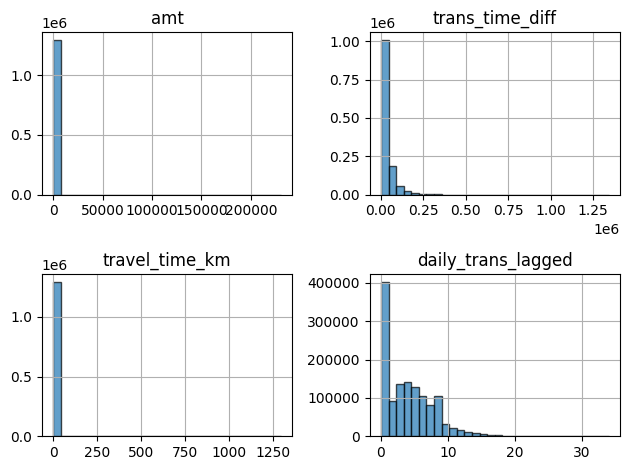

In [14]:
# 5. Distribution of all numeric features (histograms)
ax5 = plt.subplot(3, 2, 5)

# Select specific columns
selected_cols = ['amt', 'trans_time_diff', 'travel_time_km', 'daily_trans_lagged']

# Plot histograms
X[selected_cols].hist(ax=ax5, bins=30, alpha=0.7, edgecolor='black')
ax5.set_title('Numeric Features Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()

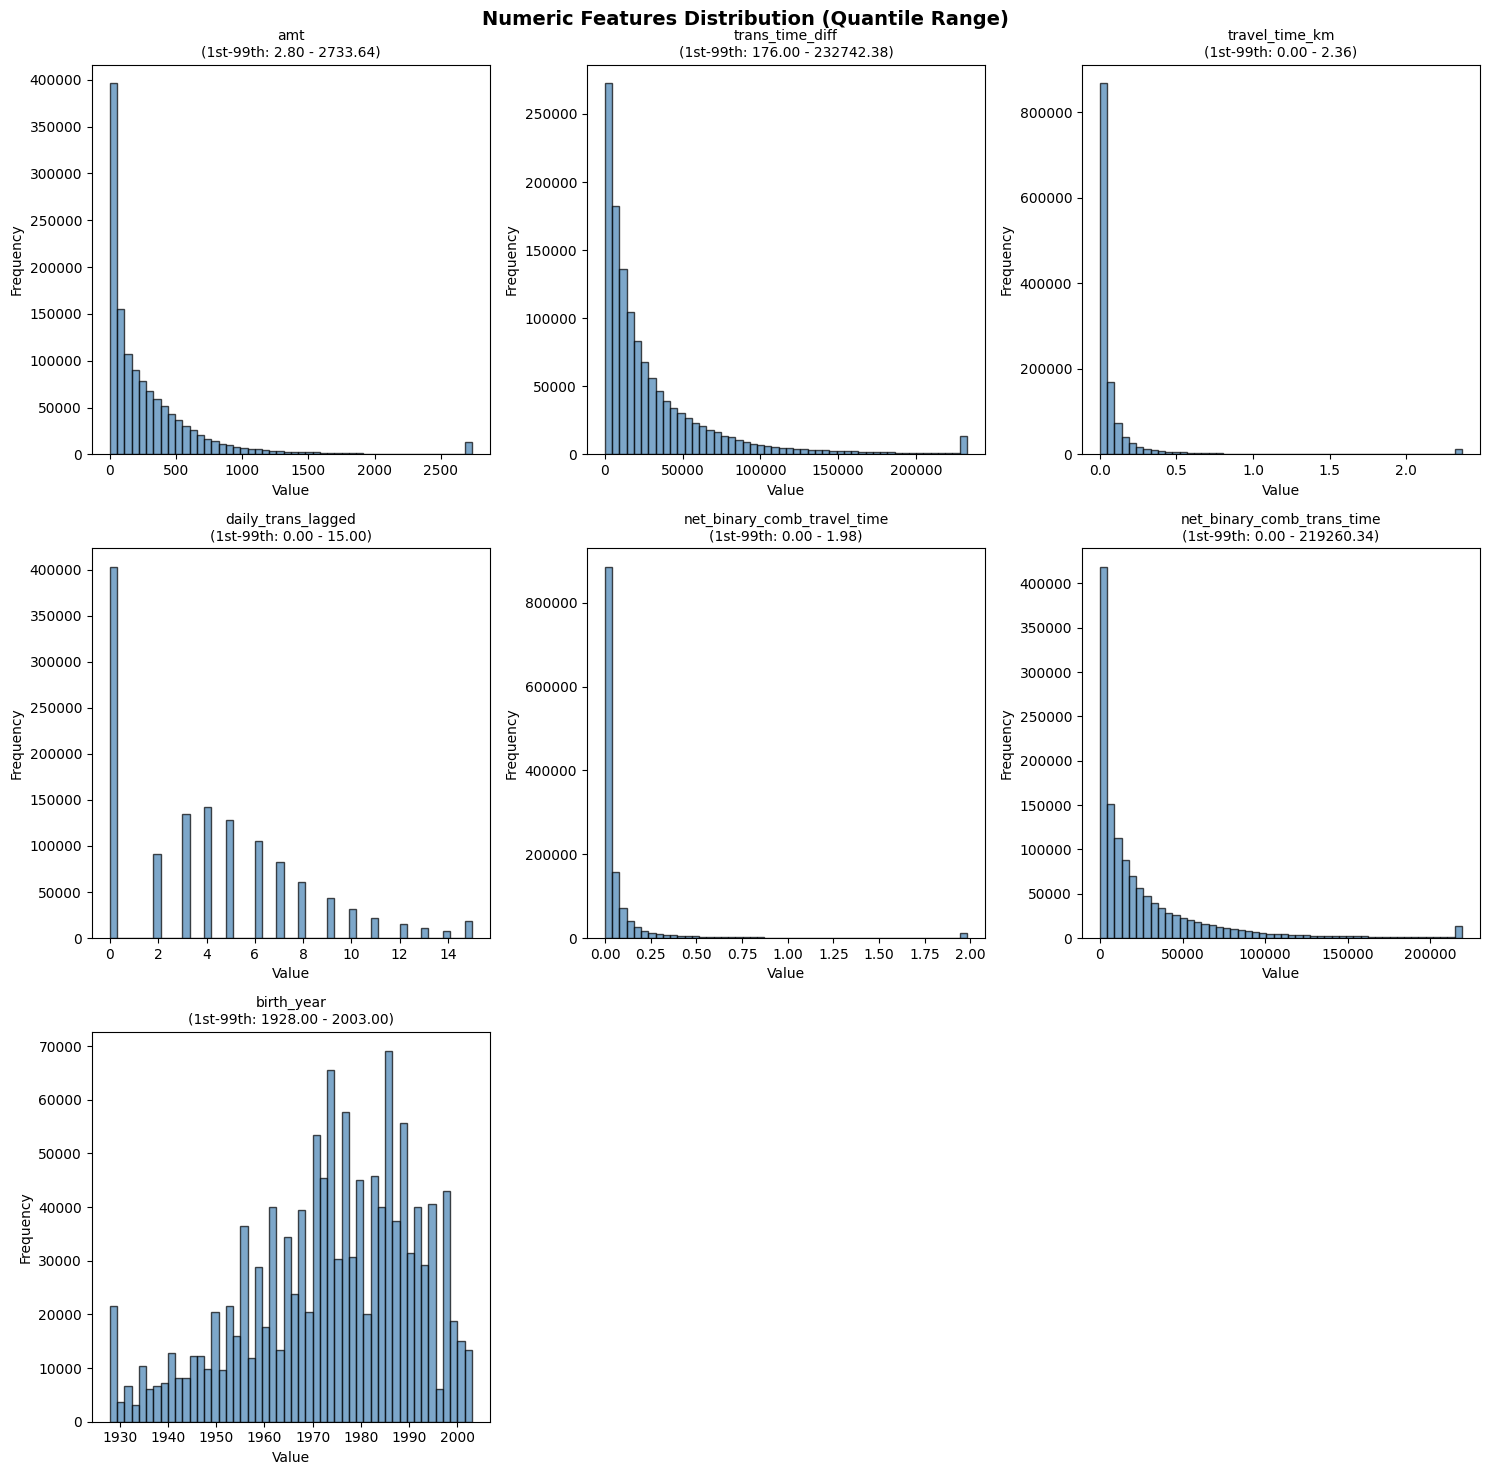

In [15]:
# 5. Distribution of all numeric features (clipped to quantile range)
selected_cols = ['amt', 'trans_time_diff', 'travel_time_km', 'daily_trans_lagged',
                 'net_binary_comb_travel_time', 'net_binary_comb_trans_time', 'birth_year']

# Calculate number of rows and columns needed
n_cols = len(selected_cols)
n_plot_cols = 3  # 3 columns per row
n_plot_rows = (n_cols + n_plot_cols - 1) // n_plot_cols  # Ceiling division

# Create subplots
fig, axes = plt.subplots(n_plot_rows, n_plot_cols, figsize=(15, 5*n_plot_rows))
axes = axes.flatten() if n_plot_rows > 1 else [axes]

for i, col in enumerate(selected_cols):
    # Clip to 1st and 99th percentile
    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)
    X_clipped = X[col].clip(lower, upper)
    
    # Plot histogram
    axes[i].hist(X_clipped, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}\n(1st-99th: {lower:.2f} - {upper:.2f})', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for i in range(len(selected_cols), len(axes)):
    axes[i].remove()

plt.suptitle('Numeric Features Distribution (Quantile Range)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

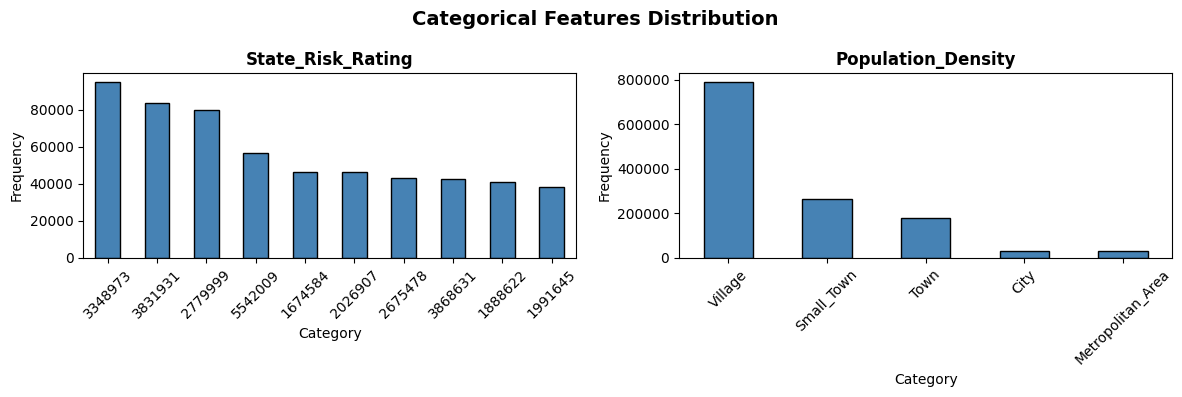

In [16]:
# Categorical variables visualization (separate plots)
categorical_cols = ['State_Risk_Rating', 'Population_Density']

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(12, 4))

for i, col in enumerate(categorical_cols):
    X[col].value_counts().head(10).plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

II.1) Feature Representation
TODO:
By using a ordinal range/categories for the variables,  it results in some better model performances. 
(Linear SVM, Logistic Regression) -Linear SVM for this data not used.
Whereas we will use the scaled integer values, for our tree based models. (XGBoost, LightGBM)  

The following Variables are therefore transformed:

- City Population
- State Risk Rating

Ordinal text variables:
Following the Lab4 - OrdinalEncoder will be used from the preprocessing module in Scikit-learn. 

## Preprocessing and Scaling different for the steps: LASSO - LSVM | LightGBM - XGBoost

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Preprocessing with encoding 

preprocessor = ColumnTransformer([
    ('state_risk', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['State_Risk_Rating']),
    ('population', OrdinalEncoder(categories=[['Village', 'Small_Town', 'Town', 'City', 'Metropolitan_Area']], handle_unknown='use_encoded_value', unknown_value=-1), ['Population_Density']),
    #('generation', OrdinalEncoder(categories=[['War_generation', 'Boomer', 'Gen X', 'Millennials', 'Gen Z']], handle_unknown='use_encoded_value', unknown_value=-1), ['generation']),
    ('pass', 'passthrough', [
        'amt', 'trans_time_diff', 
        'travel_time_km', 'daily_trans_lagged', 
        'net_binary',  'birth_year',
        'net_binary_comb_trans_time','net_binary_comb_travel_time'
    ]),  # unchanged variables
]) 

Maybe Winsorization for some variables (extreme outliers....), therefore cutting them...

## Light GBM as feature selection

To filtering useless features and also checking the hirarchy of our highly multicollinearated features, to make our final decision about the model input features, LightGBM is used. 
This approach follows the publication by S. Shi et al. (2025, p. 3): "We apply LightGBM as the tool to conduct an #automatic feature selection process.LightGBM, developed by Microsoft in 2017, is a tree-based gradient-boosting framework. Its most extraordinary advantages are efficiency and distributed computing. There are built-in functions that can calculate feature importance scores automatically and visualize the sortation of importance."

In [18]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline
# pipeline with LightGBM (Non Linear relationships)
pipeline_LGB = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        class_weight='balanced'
    ))
])

In [19]:
# After creating X, verify amount is still realistic
print("Amount in X (after selection):")
print(f"Min: {X['amt'].min():.2f}")
print(f"Max: {X['amt'].max():.2f}")
print(f"Mean: {X['amt'].mean():.2f}")
print(f"Unique values (first 10): {X['amt'].value_counts().head(10)}")

Amount in X (after selection):
Min: 0.52
Max: 230381.58
Mean: 334.32
Unique values (first 10): amt
38.731176     1
205.568402    1
86.873989     1
78.630423     1
65.831735     1
4.383536      1
68.876707     1
912.959695    1
42.668269     1
543.884060    1
Name: count, dtype: int64


In [20]:
pipeline_LGB.fit(X, y)

feature_importance = pipeline_LGB.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': pipeline_LGB.named_steps['preprocessor'].get_feature_names_out(),
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

[LightGBM] [Info] Number of positive: 7506, number of negative: 1289169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1445
[LightGBM] [Info] Number of data points in the train set: 1296675, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

Tree based Multicollinearity is not an issue!

The result of LGBM leads to the following list of features: 
All amount variables are relevant, which is to PAPER CITATION!.
Daily_transactions was excluded as weekly_transactions provides a more stable and comprehensive measure of transaction frequency while capturing the same underlying pattern. Net_binary was retained over net_binary_comb_trans_time due to its stronger predictive signal. Birth_year was kept instead of the generation classification variable, because it showed higher importance.

In [21]:
import pandas as pd
correlation_matrix = pd.DataFrame({
    'amt': X['amt'],
    #: X[], not allowed because global variable!
    #'Amount_Outlier_bin_comb_amt': X['Amount_Outlier_bin_comb_amt'], same problem
    'travel_time_km': X['travel_time_km'], # Out
    'net_binary_comb_travel_time': X['net_binary_comb_travel_time'], 
    'net_binary_comb_trans_time': X['net_binary_comb_trans_time'],
    'trans_time_diff': X['trans_time_diff'] # Out
}).corr()
correlation_matrix

,amt,travel_time_km,net_binary_comb_travel_time,net_binary_comb_trans_time,trans_time_diff
amt,1.000000,0.001547,-0.000004,-0.004556,-0.002203
travel_time_km,0.001547,1.000000,0.930004,-0.026773,-0.030301
net_binary_comb_travel_time,-0.000004,0.930004,1.000000,-0.023874,-0.027345
net_binary_comb_trans_time,-0.004556,-0.026773,-0.023874,1.000000,0.892473
trans_time_diff,-0.002203,-0.030301,-0.027345,0.892473,1.000000


## Selection of Features

In [22]:
# Feature Update.
relevant_Feat=['amt',
 'daily_trans_lagged',
 #'dist_client_merchant', # ERROR perfect predictability
 #'trans_time_diff', OUT!
 'travel_time_km',
 #'daily_trans_lagged', OUT!
 'net_binary_comb_travel_time', # Error 
 'net_binary_comb_trans_time', # error predictability
 #'Amount_Outlier_bin_comb_amt',
 'birth_year',
 #'weekly_transactions',
 #'net_binary', OUT!
 #'Amount_Outlier_bin', OUT!
 'State_Risk_Rating',
 #'generation', OUT!
 'Population_Density']

Mentioned models for CC Fraud Detection in 

Dornadula, V. N., & Geetha, S. (2019). Credit Card Fraud Detection using Machine Learning Algorithms. Procedia Computer Science, 165, 631–641. https://doi.org/10.1016/j.procs.2020.01.057

XGBoost, KNN, SVM.

Decision to use XGBoost & LinearSVM (instead of KNN), because of more dimensionalities and also faster calculation.

Also in:
(Tiwari et al., 2021, p. 4):"Support Vector Machines  Support vector machines or SVMs are linear classifiers as stated in [5] that work in high dimensionality because in high-dimensions, a non-linear task in input becomes linear and hence this makes SVMs highly useful for detecting frauds. Due to its two most important features that is a kernel function to represent classification function in the dot product of input data point projection, and the fact that it tries finding a hyperplane to maximize separation between classes while minimizing overfitting of training data, it provides a very high generalization capability."

In [23]:
print("Columns in X:", X.columns.tolist())
print("\nIs 'is_fraud' in X?", 'is_fraud' in X.columns)

Columns in X: ['amt', 'trans_time_diff', 'travel_time_km', 'daily_trans_lagged', 'net_binary_comb_travel_time', 'net_binary_comb_trans_time', 'birth_year', 'net_binary', 'State_Risk_Rating', 'Population_Density']

Is 'is_fraud' in X? False


In [24]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform

In [25]:
# Update in the preprocessor:
relevant_feat_pass = relevant_Feat.copy()
relevant_feat_pass.remove('State_Risk_Rating')
relevant_feat_pass.remove('Population_Density')

preprocessor = ColumnTransformer([
    ('state_risk', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['State_Risk_Rating']),
    ('population', OrdinalEncoder(categories=[['Village', 'Small_Town', 'Town', 'City', 'Metropolitan_Area']], handle_unknown='use_encoded_value', unknown_value=-1), ['Population_Density']),
    #('generation', OrdinalEncoder(categories=[['War_generation', 'Boomer', 'Gen X', 'Millennials', 'Gen Z']], handle_unknown='use_encoded_value', unknown_value=-1), ['generation']),
    ('pass', 'passthrough',relevant_feat_pass),  # unchanged variables
]) 

In [ ]:
## XGBoost as Model
#preprocessor = preprocessor.transformers.pop(2) #dropping generation encoding

pipeline_xgboost = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])
pipeline_xgboost

In [28]:
hiperparam_distributions = {
    'classifier__n_estimators': randint(50, 100),           # Number of trees
    'classifier__max_depth': randint(3, 10),                # Tree depth - pretty high with 8
    'classifier__learning_rate': uniform(0.01, 0.3),        # Step size shrinkage - learning rate seems about 5% reasonable
    'classifier__subsample': uniform(0.6, 0.4),             # Row sampling
    'classifier__colsample_bytree': uniform(0.6, 0.4),      # Column sampling
    'classifier__min_child_weight': randint(1, 10),         # Min instances in leaf
    'classifier__gamma': uniform(0, 0.5),                   # Min loss reduction
    'classifier__reg_alpha': uniform(0, 1),                 # L1 regularization
    'classifier__reg_lambda': uniform(0.5, 1.5)             # L2 regularization
}

In [ ]:
randomized_search_xgb = RandomizedSearchCV(
    pipeline_xgboost,
    hiperparam_distributions,
    n_iter=10,
    cv=5, # cross validation 5 fold
    scoring={'roc_auc': 'roc_auc',
        'accuracy': 'accuracy',
        'recall':'recall',
        'f1':'f1'},
        #'precision': 'precision'}, #precision is useless without testing on testset 
    refit='recall',                 
    random_state=42,
    n_jobs=-1,                        #parallel processing on mkl optinmized Intel 
    verbose=1 
)
randomized_search_xgb

In [48]:
x = X[relevant_Feat]
x.head(5)

,amt,daily_trans_lagged,travel_time_km,net_binary_comb_travel_time,net_binary_comb_trans_time,birth_year,State_Risk_Rating,Population_Density
0,38.731176,0,0.000000,0.000000,0.0,1986,2353556,Village
1,205.568402,0,0.001806,0.001806,71862.0,1986,2353556,Village
2,86.873989,4,2.755731,2.755731,159.0,1986,2353556,Village
3,78.630423,4,0.033509,0.033509,13838.0,1986,2353556,Village
4,65.831735,4,0.305505,0.305505,1952.0,1986,2353556,Village


In [49]:
randomized_search_xgb.fit(x, y)
print("Best params:", randomized_search_xgb.best_params_)
print("Best score:", randomized_search_xgb.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/sarima/anaconda3/envs/mkl_optimized/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sarima/anaconda3/envs/mkl_optimized/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sarima/anaconda3/envs/mkl_optimized/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

Best params: {'classifier__colsample_bytree': np.float64(0.9579309401710595), 'classifier__gamma': np.float64(0.29894998940554257), 'classifier__learning_rate': np.float64(0.28656227050693506), 'classifier__max_depth': 8, 'classifier__min_child_weight': 7, 'classifier__n_estimators': 89, 'classifier__reg_alpha': np.float64(0.8445338486781514), 'classifier__reg_lambda': np.float64(1.6209801652060714), 'classifier__subsample': np.float64(0.815876852955632)}
Best score: 0.2236858516869801


In [50]:
from xgboost import XGBClassifier
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('classifier', XGBClassifier(
        n_estimators = randomized_search_xgb.best_params_['classifier__n_estimators'],
        max_depth = randomized_search_xgb.best_params_['classifier__max_depth'],
        learning_rate = randomized_search_xgb.best_params_['classifier__learning_rate'],
        subsample = randomized_search_xgb.best_params_['classifier__subsample'],
        colsample_bytree = randomized_search_xgb.best_params_['classifier__colsample_bytree'],
        min_child_weight = randomized_search_xgb.best_params_['classifier__min_child_weight'],
        gamma = randomized_search_xgb.best_params_['classifier__gamma'],
        reg_alpha  = randomized_search_xgb.best_params_['classifier__reg_alpha'],
        reg_lambda = randomized_search_xgb.best_params_['classifier__reg_lambda'],
        random_state=42,  
        eval_metric='logloss'  
    ))
])

In [51]:
X_test = cc_test[relevant_Feat].to_pandas()  
y_test = cc_test['is_fraud'].to_pandas()
X_test

,amt,daily_trans_lagged,travel_time_km,net_binary_comb_travel_time,net_binary_comb_trans_time,birth_year,State_Risk_Rating,Population_Density
0,869.349761,0,0.000000,0.000000,0.0,1986,2353556,Village
1,240.405621,2,0.007045,0.007045,11994.0,1986,2353556,Village
2,224.815967,0,0.003757,0.003757,55977.0,1986,2353556,Village
3,490.272295,2,0.002136,0.002136,27238.0,1986,2353556,Village
4,927.203388,0,0.000995,0.000995,75383.0,1986,2353556,Village
...,...,...,...,...,...,...,...,...
555714,532.528316,0,0.013673,0.013673,8077.0,1956,2675478,Village
555715,28.637996,5,0.008705,0.000000,0.0,1956,2675478,Village
555716,334.321254,5,0.003377,0.003377,21729.0,1956,2675478,Village
555717,200.734841,5,1.083131,1.083131,101.0,1956,2675478,Village


In [52]:
threshold = 0.25 # unbalanced data therefore lower threshold, trial and error lead to 0.25

In [53]:
# Predict on test set
best_pipeline.fit(x, y) 
y_pred_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_test >= threshold).astype(int)

# Calculate performance
from sklearn.metrics import roc_auc_score, accuracy_score,  precision_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report

auc_test = roc_auc_score(y_test, y_pred_test)
accuracy_test = accuracy_score(y_test, y_pred_class)
#  metrics for imbalanced data
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)


auc_test,accuracy_test

(0.8592242704986439, 0.9941823115639379)

In [59]:
print(f"Best XGBoost Model results")
print(f'precision:{precision} recall: {recall}  f1: {f1}')


Best XGBoost Model results
precision:0.3547486033519553 recall: 0.17762237762237762  f1: 0.23671947809878843


## RandomForest as challenger model

Same procedure but via RandomForest as validity check and performance benchmark.

1. Step Random Forest Pipeline definition. 
    - preprocessor (as before) & classifier set to RandomForest (RF)

In [62]:
from sklearn.ensemble import RandomForestClassifier

pipeline_RF = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', RandomForestClassifier(
        random_state=42
    ))
])
pipeline_RF

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('state_risk', ...), ('population', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

2. Step: Random hyperparameter construction for RF

In [73]:

hiperparam_distributions_RF = {
    'classifier__n_estimators': randint(10, 65),           # Number of trees
    'classifier__max_depth': randint(3, 10),                # Tree depth
    'classifier__min_samples_split': randint(2, 20),        # Min samples to split a node
    'classifier__min_samples_leaf': randint(1, 10),         # Min samples in leaf node
    'classifier__max_features': ['sqrt', 'log2', None],     # Number of features to consider
    'classifier__bootstrap': [True, False],                 # Bootstrap samples or not
    'classifier__criterion': ['gini', 'entropy']            # Split quality metric
}
hiperparam_distributions_RF

{'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x7e349ef5f110>,
 'classifier__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x7e34a41ce810>,
 'classifier__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x7e349ef6e2d0>,
 'classifier__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x7e34a7749350>,
 'classifier__max_features': ['sqrt', 'log2', None],
 'classifier__bootstrap': [True, False],
 'classifier__criterion': ['gini', 'entropy']}

3. Step usage of randomized hyperparameters in the RandomForest pipeline including Cross Validation.

In [ ]:
randomized_search_rf = RandomizedSearchCV(
    pipeline_RF,                       # Changed for pipeline_RF
    hiperparam_distributions_RF,       # Change for RF 
    n_iter=10,                         # from here on, same to XGBoost
    cv=5,
    scoring={
        'roc_auc': 'roc_auc',
        'accuracy': 'accuracy',
        'recall': 'recall',
        'f1': 'f1'
    },
    refit='recall',                 # Optimize for recall
    random_state=42,
    n_jobs=-1,                      #parallel processing on mkl optinmized Intel
    verbose=1
)
randomized_search_rf

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__bootstrap': [True, False], 'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': <scipy.stats....x7e349f0c5c90>, 'classifier__max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'f1': 'f1', 'recall': 'recall', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffl

4. Step fitting RandomForest via defined Pipeline and Hyperparameter and exporting best parameter scores.

In [74]:
randomized_search_rf.fit(x, y)
print("Best params:", randomized_search_rf.best_params_)
print("Best score:", randomized_search_rf.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'classifier__bootstrap': False, 'classifier__criterion': 'entropy', 'classifier__max_depth': 8, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 11, 'classifier__n_estimators': 13}
Best score: 0.14215183663620612


5. Step using the best hyperparameter for the RF.

In [75]:
RF_best_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('classifier', RandomForestClassifier(
        n_estimators = randomized_search_rf.best_params_['classifier__n_estimators'],
        max_depth = randomized_search_rf.best_params_['classifier__max_depth'],
        min_samples_split = randomized_search_rf.best_params_['classifier__min_samples_split'],
        min_samples_leaf = randomized_search_rf.best_params_['classifier__min_samples_leaf'],
        max_features = randomized_search_rf.best_params_['classifier__max_features'],
        bootstrap = randomized_search_rf.best_params_['classifier__bootstrap'],
        criterion = randomized_search_rf.best_params_['classifier__criterion'],
        random_state=42
    ))
])

In [77]:
# Predict on test set
RF_best_pipeline.fit(x, y)  #Here RF_best_pipeline (instead XGboost)
y_pred_test = RF_best_pipeline.predict_proba(X_test)[:, 1] #Here RF_best_pipeline (instead XGboost)
y_pred_class = (y_pred_test >= threshold).astype(int)

# Calculate performance
from sklearn.metrics import roc_auc_score, accuracy_score,  precision_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report

auc_test = roc_auc_score(y_test, y_pred_test)
accuracy_test = accuracy_score(y_test, y_pred_class)
#  metrics for imbalanced data
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)


auc_test,accuracy_test

(0.8948488534639618, 0.9953861573924951)

In [78]:
print(f"Best RandomForest Model ")
print(f'precision:{precision} recall: {recall}  f1: {f1}')


Best RandomForest Model 
precision:0.3766921718658034 recall: 0.29836829836829837  f1: 0.33298647242455776


## Analysis.

### End for the junk below.
Write out the steps and research from here on!

In [55]:
# Try different thresholds to see which maximizes F1
thresholds = [0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
results = []

for thresh in thresholds:
    y_pred_class = (y_pred_test >= thresh).astype(int)
    precision = precision_score(y_test, y_pred_class)
    recall = recall_score(y_test, y_pred_class)
    f1 = f1_score(y_test, y_pred_class)
    results.append((thresh, precision, recall, f1))
    print(f"Threshold {thresh:.2f}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}")

# Find best
best = max(results, key=lambda x: x[3])
print(f"\nBest F1: {best[3]:.3f} at threshold {best[0]:.2f}")

Threshold 0.03: P=0.073, R=0.519, F1=0.128
Threshold 0.05: P=0.114, R=0.441, F1=0.181
Threshold 0.10: P=0.165, R=0.365, F1=0.227
Threshold 0.15: P=0.202, R=0.323, F1=0.249
Threshold 0.20: P=0.228, R=0.289, F1=0.255
Threshold 0.25: P=0.255, R=0.264, F1=0.260
Threshold 0.30: P=0.278, R=0.243, F1=0.260
Threshold 0.35: P=0.298, R=0.223, F1=0.255
Threshold 0.40: P=0.314, R=0.208, F1=0.250
Threshold 0.45: P=0.330, R=0.190, F1=0.241
Threshold 0.50: P=0.355, R=0.178, F1=0.237

Best F1: 0.260 at threshold 0.25


In [36]:
auc_test, accuracy_test

(0.906185792996951, 0.9961347371603274)

In [37]:
fraud_rate = y_test.mean()
print(f"Fraud rate in test: {fraud_rate:.4f}")

Fraud rate in test: 0.0039


In [38]:
def plot_parameter_impact_simple(search_results):
    results = pd.DataFrame(search_results.cv_results_)
    
    # Extract parameters
    param_cols = [col for col in results.columns if col.startswith('param_classifier__')]
    
    for param in param_cols:
        param_name = param.replace('param_classifier__', '')
        param_means = results.groupby(param)['mean_test_score'].mean()
        
        plt.figure(figsize=(8, 4))
        plt.plot(param_means.index.astype(str), param_means.values, 'o-', linewidth=2, color='blue')
        plt.xlabel(param_name)
        plt.ylabel('Mean CV Score (AUC)')
        plt.title(f'Impact of {param_name}')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# This will show each parameter in a separate plot
plot_parameter_impact_simple(randomized_search_xgb)

KeyError: 'Column not found: mean_test_score'

In [ ]:
# Show top 5 parameter combinations
results = pd.DataFrame(randomized_search_xgb.cv_results_)
top5 = results.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
top5

In [ ]:
best_xgboost = randomized_search_xgb.best_estimator_

Concept of Voting Classifier.
Lasso Regression, LightGBM -> Feature Selection
Since the  XGBoost, LSVC as Model -> Voting if 


# Analyis

In qualitative variable analysis, the
- construction of our Amount Outlier might be discussed. (Values 1.5, 2, 2.5 etc * IQR in threshold)  
- City Population might be differently calculated, by choosing different ranges or more/less categories...
- generational variable

Set Up Discussions:
But a feature could be useful in LightGBM but useless in XGBoost (and vice versa) because:
Different splitting criteria (gain vs. gini vs. mse)
Different handling of categorical features
Different tree growth strategies (leaf-wise vs. depth-wise)